In [1]:
from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
sns.set(style="darkgrid")
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV,cross_val_score
from sklearn.metrics import balanced_accuracy_score,mean_squared_error
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score,cross_val_predict

path= "/content/drive/MyDrive/Parkinsson disease.csv"
df = pd.read_csv(path)
df

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,phon_R01_S50_2,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,...,0.07008,0.02764,19.517,0,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,phon_R01_S50_3,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,...,0.04812,0.01810,19.147,0,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,phon_R01_S50_4,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,...,0.03804,0.10715,17.883,0,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,phon_R01_S50_5,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,...,0.03794,0.07223,19.020,0,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

**No Null value detected**

Renaming

In [4]:
df.rename(columns = {
                     'MDVP:Fo(Hz)': 'av_voc_hz',
                     'MDVP:Fhi(Hz)': 'max_voc_hz',
                     'MDVP:Flo(Hz)': 'min_voc_hz',
                     'MDVP:Jitter(%)': 'frq_percent',
                     'MDVP:Jitter(Abs)': 'frq_abs',
                     'MDVP:RAP': 'frq_rap',
                     'MDVP:PPQ': 'frq_ppq',
                     'Jitter:DDP': 'frq_ddp',
                     'MDVP:Shimmer': 'amp',
                     'MDVP:Shimmer(dB)': 'amp_db',
                     'Shimmer:APQ3': 'amp_apq3',
                     'Shimmer:APQ5': 'amp_apq5',
                     'MDVP:APQ': 'amp_apq',
                     'Shimmer:DDA': 'amp_dda',
                    },
          inplace = True)
df.head()

,name,av_voc_hz,max_voc_hz,min_voc_hz,frq_percent,frq_abs,frq_rap,frq_ppq,frq_ddp,amp,...,amp_dda,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


dropping 'name'

In [5]:
df.drop('name', axis = 1, inplace = True)
df.head()

,av_voc_hz,max_voc_hz,min_voc_hz,frq_percent,frq_abs,frq_rap,frq_ppq,frq_ddp,amp,amp_db,...,amp_dda,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [6]:
df.duplicated().sum()

0

In [7]:
df.describe()

,av_voc_hz,max_voc_hz,min_voc_hz,frq_percent,frq_abs,frq_rap,frq_ppq,frq_ddp,amp,amp_db,...,amp_dda,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


**Range of different features**

In [8]:
#df_hist=df.loc[:,df.columns!='status']

In [9]:
#df_hist.hist(figsize=(25,20))
#plt.show()

**Status 1 = PD, status 0 = healthy. Let's see the range of average focal frequency among the PD detected**

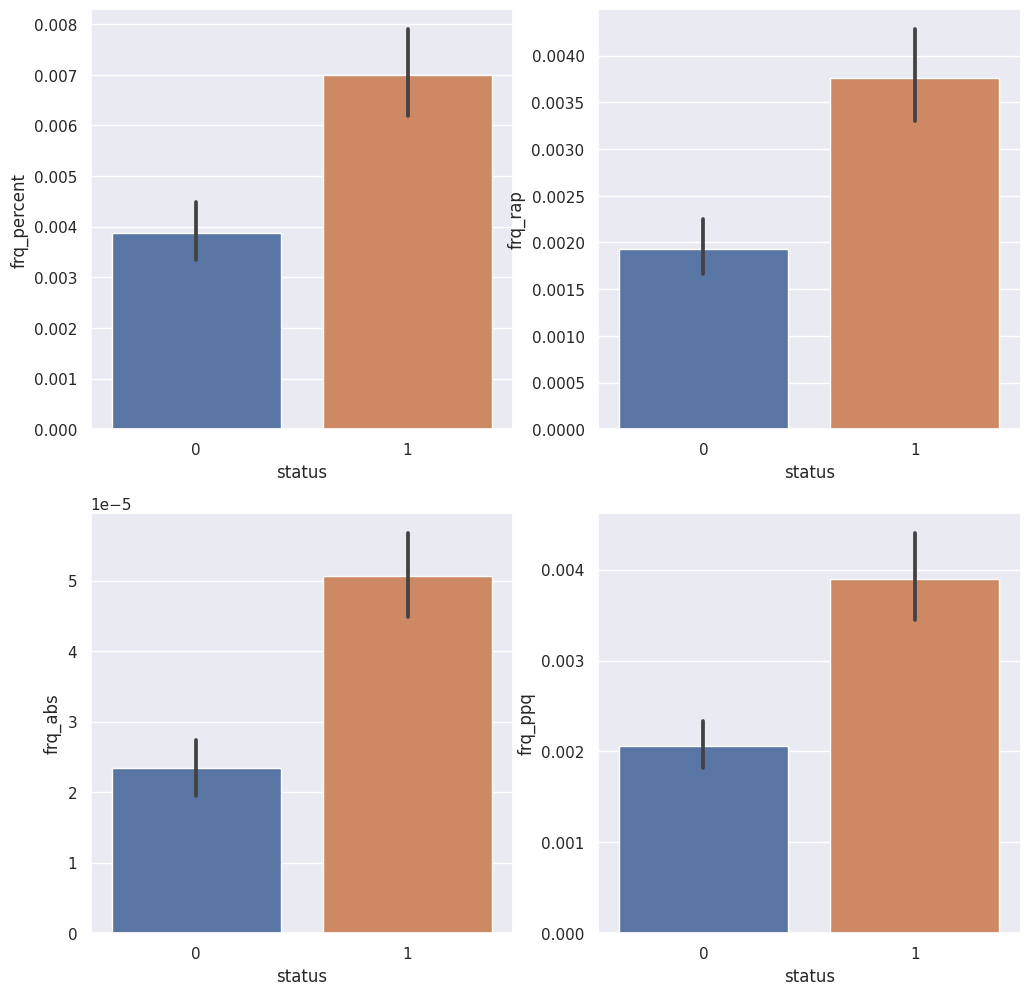

In [10]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12,12))

sns.barplot(x="status", y="frq_percent",data=df, ax = ax[0,0]);

sns.barplot(x="status", y="frq_rap",data=df, ax = ax[0,1]);

sns.barplot(x="status", y="frq_abs",data=df, ax = ax[1,0]);

sns.barplot(x="status", y="frq_ppq",data=df, ax = ax[1,1]);

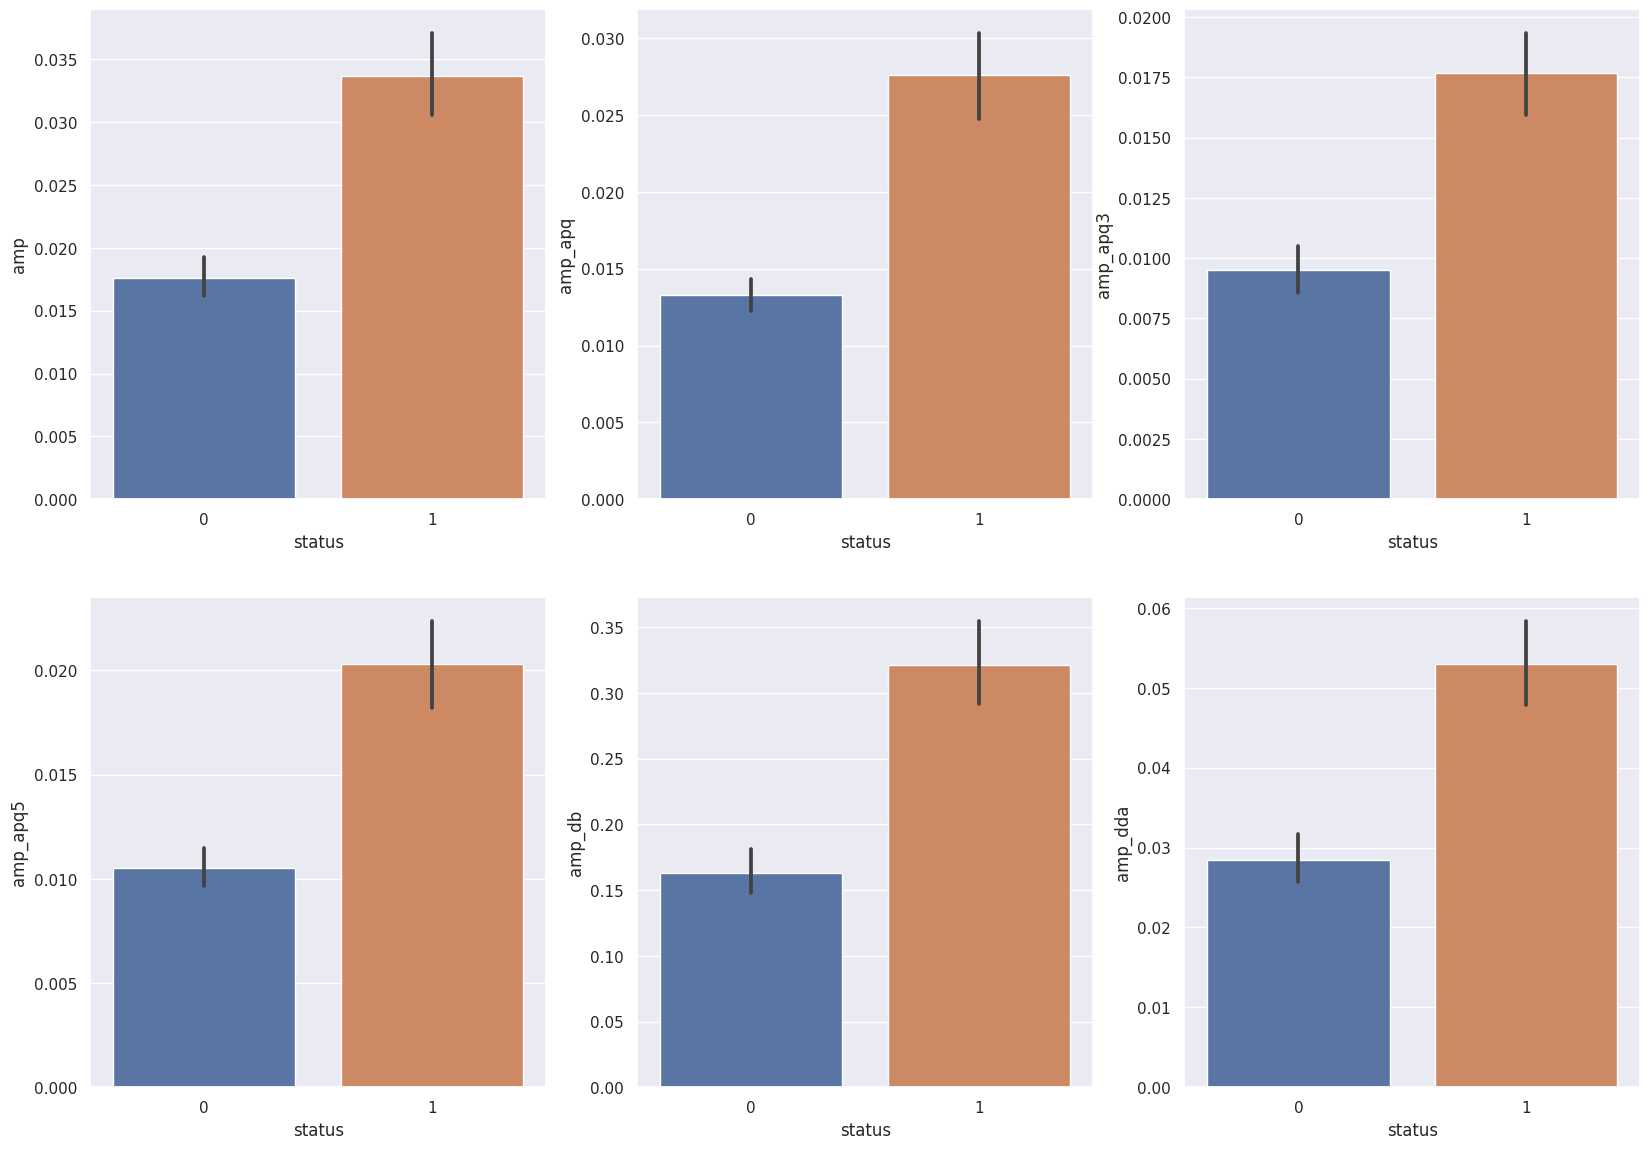

In [11]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(20,14))

sns.barplot(x="status", y="amp",data=df, ax = ax[0,0]);

sns.barplot(x="status", y="amp_apq",data=df, ax = ax[0,1]);

sns.barplot(x="status", y="amp_apq3",data=df, ax = ax[0,2]);

sns.barplot(x="status", y="amp_apq5",data=df, ax = ax[1,0]);

sns.barplot(x="status", y="amp_db",data=df, ax = ax[1,1]);

sns.barplot(x="status", y="amp_dda",data=df, ax = ax[1,2]);

In [12]:
sns.lineplot(x='spread1', y="none", hue = 'status', data=df);

ValueError: ignored

Are HNR and NHR in a proportional relation? 

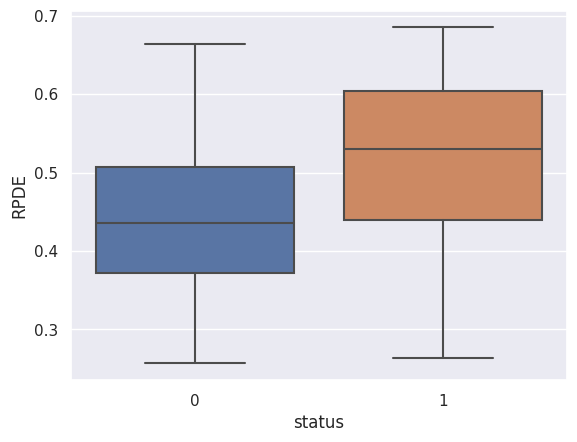

In [21]:
sns.boxplot(x="status", y="RPDE",data=df);

In [ ]:
sns.boxplot(x="status", y="NHR",data=df);

In [ ]:
sns.relplot(x="HNR", y="NHR", data=df, hue = "status", kind="scatter");

In [ ]:
cor = df.corr()
plt.figure(figsize = (6,8))
sns.heatmap(cor, cbar=0, linewidths=2,vmax=1, vmin=0, square=True, cmap='Blues')

In [ ]:
plt.figure(figsize=(16,5))
sns.swarmplot(x="amp", y="amp_db", hue="status", data=df)

In [ ]:
plt.figure(figsize=(16,5))
sns.stripplot(x="spread1", y="PPE", hue = "status", data=df, size=8)

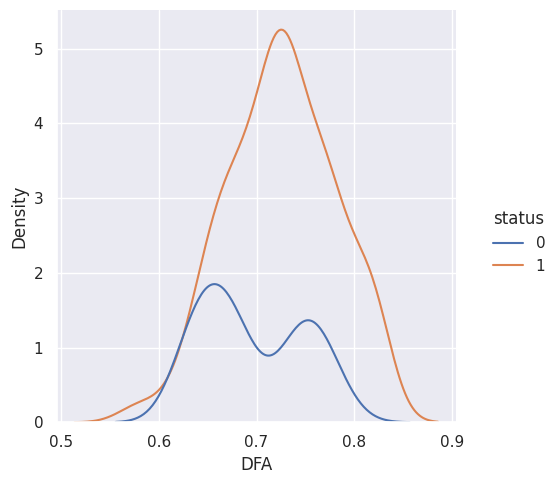

In [44]:
sns.displot(data=df, x="DFA", kind="kde", hue = "status")

<Axes: xlabel='status', ylabel='spread2'>

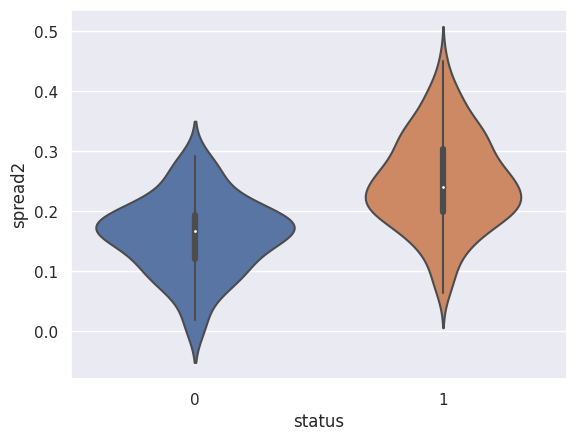

In [46]:
sns.violinplot(x='status', y='spread2', data=df)

<Axes: xlabel='status', ylabel='D2'>

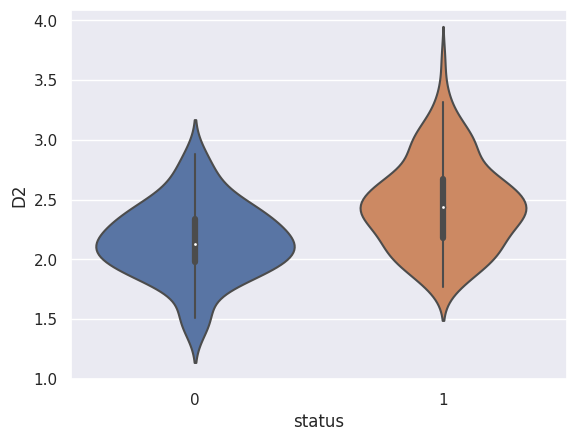

In [15]:
sns.violinplot(x='status', y='D2', data=df)

<Axes: xlabel='status', ylabel='DFA'>

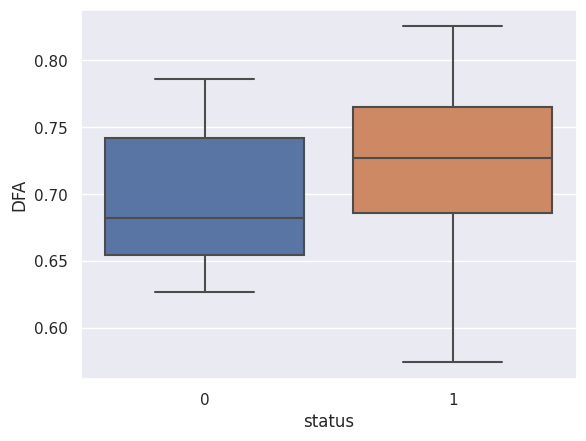

In [37]:
sns.boxplot(x='status', y='DFA', data=df)

In [41]:
nstatus = df[df['status'] == 0]

ValueError: ignored